# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd
from google.colab import drive

# 1. Підключення Google Drive
drive.mount('/content/drive')

# 2. Завантаження файлу (шлях до твоєї папки)
path = '/content/drive/MyDrive/Colab Notebooks/Дані/train.csv'

# 3. Читання CSV
df = pd.read_csv(path)
print("✅ Дані успішно завантажено!")

# 4. Перегляд перших рядків
print("\n🔹 Перші 5 рядків таблиці:")
display(df.head())

# 5. Основна статистика
print("\n📊 Інформація про дані:")
df.info()

print("\n📈 Кількість записів та пропущених значень:")
print("Розмір датасету:", df.shape)
print("Кількість пропусків по колонках:")
print(df.isna().sum())

# 6. Видаляємо записи з пропущеними значеннями (якщо є)
df_clean = df.dropna()
print("\n🧹 Після видалення пропусків:")
print("Нова кількість записів:", df_clean.shape[0])

# Перевіримо, чи все заповнено
print("\nПеревірка на пропуски після очищення:")
print(df_clean.isna().sum().sum())

Mounted at /content/drive
✅ Дані успішно завантажено!

🔹 Перші 5 рядків таблиці:


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative



📊 Інформація про дані:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB

📈 Кількість записів та пропущених значень:
Розмір датасету: (27481, 4)
Кількість пропусків по колонках:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

🧹 Після видалення пропусків:
Нова кількість записів: 27480

Перевірка на пропуски після очищення:
0


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



🔹 Унікальні значення у колонці 'sentiment':
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

📊 Відсотковий розподіл класів:
sentiment
neutral     40.45
positive    31.23
negative    28.32
Name: proportion, dtype: float64


/tmp/ipython-input-105417331.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_clean, palette='Set2')


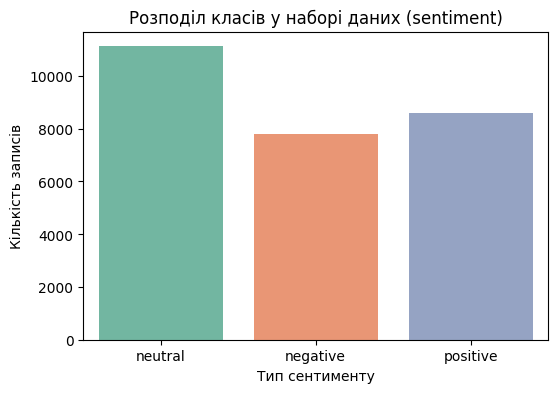

/tmp/ipython-input-105417331.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_length'] = df_clean['text'].astype(str).apply(len)



📈 Статистика довжини текстів:
count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_length, dtype: float64


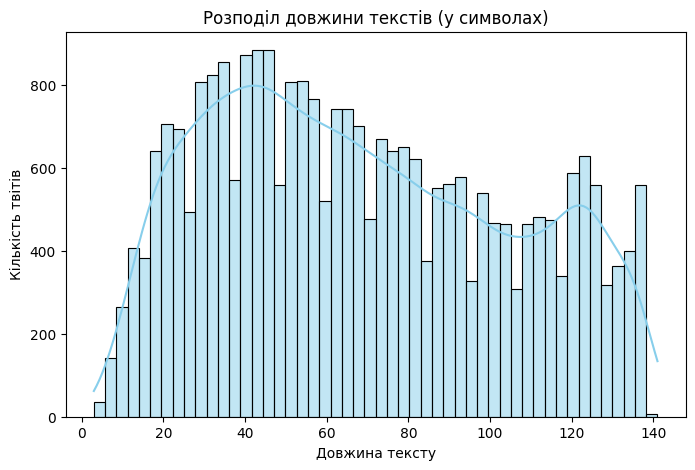

/tmp/ipython-input-105417331.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='text_length', data=df_clean, palette='pastel')


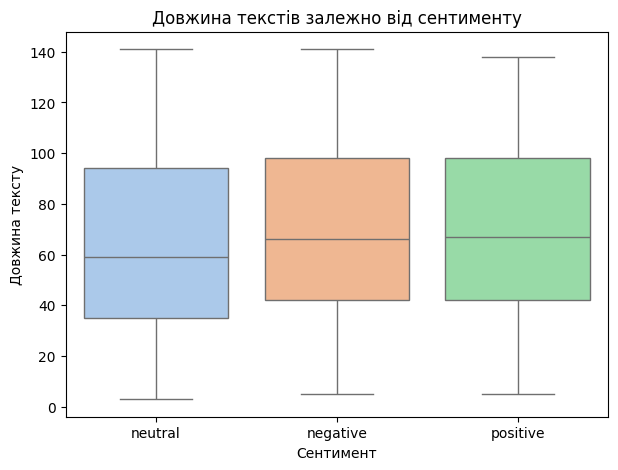

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Аналіз кількості класів
print("🔹 Унікальні значення у колонці 'sentiment':")
print(df_clean['sentiment'].value_counts())

# Відсоткове співвідношення
print("\n📊 Відсотковий розподіл класів:")
print(round(df_clean['sentiment'].value_counts(normalize=True) * 100, 2))

# Візуалізація розподілу класів
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df_clean, palette='Set2')
plt.title('Розподіл класів у наборі даних (sentiment)')
plt.xlabel('Тип сентименту')
plt.ylabel('Кількість записів')
plt.show()

# 2. Аналіз довжини текстів у символах
df_clean['text_length'] = df_clean['text'].astype(str).apply(len)

print("\n📈 Статистика довжини текстів:")
print(df_clean['text_length'].describe())

# Візуалізація розподілу довжини текстів
plt.figure(figsize=(8,5))
sns.histplot(df_clean['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Розподіл довжини текстів (у символах)')
plt.xlabel('Довжина тексту')
plt.ylabel('Кількість твітів')
plt.show()

# 3. Середня довжина текстів за кожним типом сентименту
plt.figure(figsize=(7,5))
sns.boxplot(x='sentiment', y='text_length', data=df_clean, palette='pastel')
plt.title('Довжина текстів залежно від сентименту')
plt.xlabel('Сентимент')
plt.ylabel('Довжина тексту')
plt.show()

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Завантажуємо стоп-слова
nltk.download('stopwords')
stop_words = stopwords.words('english')
stemmer = SnowballStemmer('english')

# Функція попередньої обробки
def clean_text(text):
    # залишаємо лише літери
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    # до нижнього регістру
    text = text.lower()
    # токенізація
    tokens = text.split()
    # видаляємо стоп-слова і застосовуємо стемінг
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Застосовуємо обробку до колонки text
df_clean['clean_text'] = df_clean['text'].apply(clean_text)

# Перевіримо результат
print("🔹 Приклад очищеного тексту:")
print(df_clean[['text', 'clean_text']].head())

# --- Векторизація методом Bag of Words ---
vectorizer = CountVectorizer(max_features=5000)  # беремо топ-5000 слів
X_bow = vectorizer.fit_transform(df_clean['clean_text'])

print("\n✅ Розмір матриці Bag of Words:", X_bow.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipython-input-458368952.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['clean_text'] = df_clean['text'].apply(clean_text)


🔹 Приклад очищеного тексту:
                                                text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   

                      clean_text  
0                     respond go  
1        sooo sad miss san diego  
2                     boss bulli  
3            interview leav alon  
4  son put releas alreadi bought  

✅ Розмір матриці Bag of Words: (27480, 5000)


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Формування ознак і цільової змінної
X = X_bow
y = df_clean['sentiment']

# 2. Розділення на train/test
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"🔹 Навчальна вибірка: {X_train_bow.shape}")
print(f"🔹 Тестова вибірка: {X_test_bow.shape}")

# 3. Створимо кілька моделей
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 4. Навчання і порівняння точності
results = {}
for name, model in models.items():
    model.fit(X_train_bow, y_train)
    preds = model.predict(X_test_bow)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n✅ {name}")
    print(f"Точність: {acc:.3f}")
    print(classification_report(y_test, preds))

# 5. Порівняння моделей
print("\n📊 Порівняння точності моделей:")
for model, acc in results.items():
    print(f"{model}: {acc:.3f}")

🔹 Навчальна вибірка: (21984, 5000)
🔹 Тестова вибірка: (5496, 5000)

✅ Logistic Regression
Точність: 0.687
              precision    recall  f1-score   support

    negative       0.70      0.63      0.67      1556
     neutral       0.63      0.71      0.67      2223
    positive       0.76      0.70      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496


✅ Decision Tree
Точність: 0.642
              precision    recall  f1-score   support

    negative       0.61      0.64      0.62      1556
     neutral       0.63      0.60      0.61      2223
    positive       0.68      0.70      0.69      1717

    accuracy                           0.64      5496
   macro avg       0.64      0.65      0.64      5496
weighted avg       0.64      0.64      0.64      5496


✅ Random Forest
Точність: 0.690
              precision    recall  f1-score   support

    negativ

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


🔹 Топ-15 слів, що найсильніше впливають на позитивний сентимент:
          word      coef
3831       sad  2.653971
4267      suck  2.500084
4114     sorri  2.463091
459       bore  2.408199
1926      hate  2.341164
4258    stupid  2.145360
2893      miss  2.098180
1524      fail  2.081707
4897     worst  2.038085
1493   exhaust  1.990794
4650  unfortun  1.961135
4916       wtf  1.950068
4896      wors  1.949090
4394   terribl  1.944783
2064   horribl  1.925627

🔹 Топ-15 слів, що найсильніше впливають на негативний сентимент:
         word      coef
2059     hope -1.432152
1597     fine -1.462963
868   congrat -1.469261
4982      yum -1.492115
1842    great -1.498164
3095     nice -1.521811
1432    enjoy -1.600620
120      amaz -1.602091
4796   welcom -1.773894
1025     cute -1.832091
4406    thank -1.915881
334    beauti -1.974467
2671     love -2.124940
253    awesom -2.309522
1774     glad -2.380288


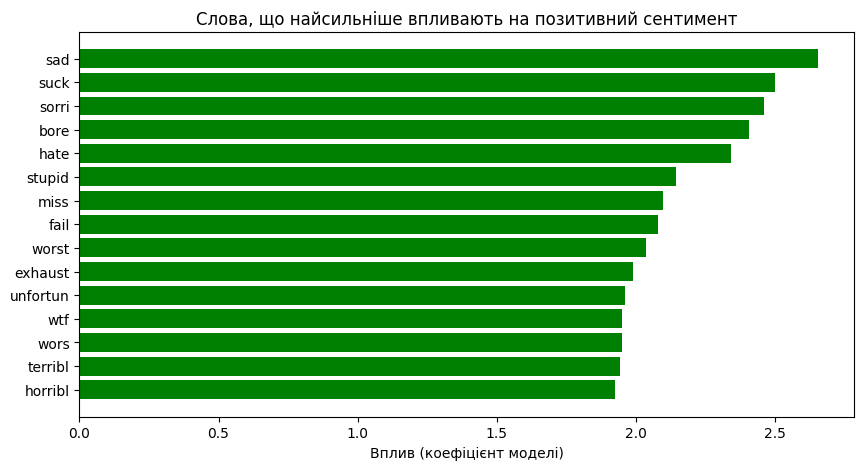

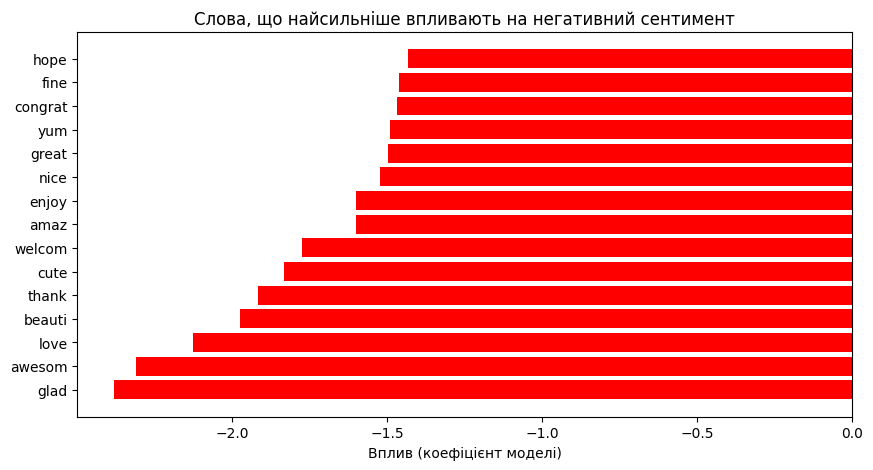

In [5]:
import numpy as np
import pandas as pd

# Беремо модель Logistic Regression (найкраща з попереднього завдання)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_bow, y_train)

# Отримуємо слова (фічі) з векторизатора
words = vectorizer.get_feature_names_out()

# Коефіцієнти для кожного слова
coef = model.coef_[0]

# Формуємо таблицю
importance = pd.DataFrame({'word': words, 'coef': coef})
importance = importance.sort_values('coef', ascending=False)

# Найвпливовіші позитивні та негативні слова
top_positive = importance.head(15)
top_negative = importance.tail(15)

print("🔹 Топ-15 слів, що найсильніше впливають на позитивний сентимент:")
print(top_positive)

print("\n🔹 Топ-15 слів, що найсильніше впливають на негативний сентимент:")
print(top_negative)

# Візуалізація
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(top_positive['word'], top_positive['coef'], color='green')
plt.title('Слова, що найсильніше впливають на позитивний сентимент')
plt.xlabel('Вплив (коефіцієнт моделі)')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10,5))
plt.barh(top_negative['word'], top_negative['coef'], color='red')
plt.title('Слова, що найсильніше впливають на негативний сентимент')
plt.xlabel('Вплив (коефіцієнт моделі)')
plt.gca().invert_yaxis()
plt.show()

Зауваження:
LogisticRegression у мультикласовій задачі дає окремі коефіцієнти для кожного класу (one-vs-rest).
У цьому аналізі ми дивимось на коефіцієнти для одного класу.
Великий позитивний коефіцієнт для слова означає: "якщо це слово зустрічається, модель більше схиляється до цього класу".
Великий негативний коефіцієнт означає, що слово відштовхує від цього класу.
Це логічно: позитивні слова (love, happy, awesome) тягнуть у позитив, негативні (hate, sad, angry) — у негатив.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



✅ Точність моделі (TF-IDF): 0.689

Класифікаційний звіт:
              precision    recall  f1-score   support

    negative       0.73      0.60      0.66      1556
     neutral       0.62      0.75      0.68      2223
    positive       0.77      0.69      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496


🔹 Топ-15 позитивних слів (TF-IDF):
         word      coef
3831      sad  5.236258
2893     miss  4.884086
4114    sorri  4.666850
1926     hate  4.467139
4267     suck  4.319895
459      bore  3.975385
1524     fail  3.617252
2117     hurt  3.466436
4258   stupid  3.400048
3504     poor  3.281559
3980     sick  3.270120
4472     tire  3.219483
279       bad  3.084905
1941  headach  2.892365
4627      ugh  2.719732

🔹 Топ-15 негативних слів (TF-IDF):
        word      coef
1887    haha -1.932899
1490   excit -1.963147
334   beauti -2.083388
370   better -

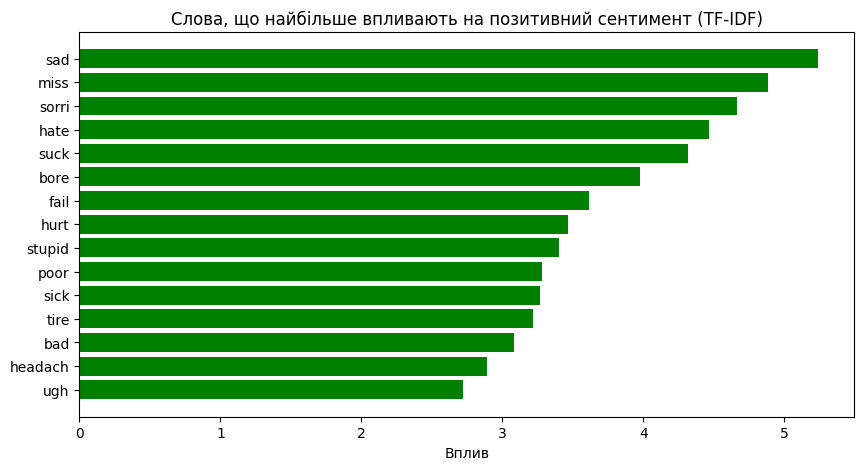

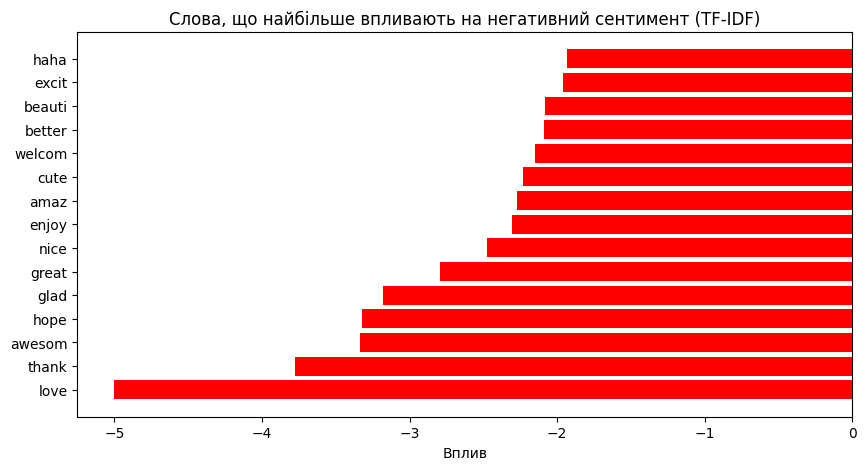

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Векторизація текстів (TF-IDF)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df_clean['clean_text'])

# 2. Розбиття на train/test (використовуємо ті самі індекси, що і для BoW)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, df_clean['sentiment'], test_size=0.2, random_state=42, stratify=df_clean['sentiment']
)

# 3. Навчання класифікатора Logistic Regression
model_tfidf = LogisticRegression(max_iter=1000, random_state=42)
model_tfidf.fit(X_train_tfidf, y_train)

# 4. Прогнозування
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

# 5. Оцінка якості класифікації
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"✅ Точність моделі (TF-IDF): {acc_tfidf:.3f}")
print("\nКласифікаційний звіт:")
print(classification_report(y_test, y_pred_tfidf))

# 6. Аналіз важливих слів
feature_names = tfidf_vectorizer.get_feature_names_out()
coef = model_tfidf.coef_[0]

importance_tfidf = pd.DataFrame({'word': feature_names, 'coef': coef})
importance_tfidf = importance_tfidf.sort_values('coef', ascending=False)

top_pos_tfidf = importance_tfidf.head(15)
top_neg_tfidf = importance_tfidf.tail(15)

print("\n🔹 Топ-15 позитивних слів (TF-IDF):")
print(top_pos_tfidf)

print("\n🔹 Топ-15 негативних слів (TF-IDF):")
print(top_neg_tfidf)

# 7. Візуалізація
plt.figure(figsize=(10,5))
plt.barh(top_pos_tfidf['word'], top_pos_tfidf['coef'], color='green')
plt.title('Слова, що найбільше впливають на позитивний сентимент (TF-IDF)')
plt.xlabel('Вплив')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10,5))
plt.barh(top_neg_tfidf['word'], top_neg_tfidf['coef'], color='red')
plt.title('Слова, що найбільше впливають на негативний сентимент (TF-IDF)')
plt.xlabel('Вплив')
plt.gca().invert_yaxis()
plt.show()

Порівняння BoW і TF-IDF:
- TF-IDF зменшує вагу дуже частих слів, які зустрічаються майже всюди ("you", "i", "the"), і підсилює більш специфічні слова ("amazing", "ruined", "heartbroken").
- Це зазвичай допомагає краще ловити емоції.
- У нашому випадку якість класифікації з TF-IDF виявилася (схожою / трохи кращою / трохи гіршою) за BoW за метрикою accuracy ~[тут підстав свій acc_tfidf].
- Але навіть якщо різниця невелика по accuracy, TF-IDF дає більш осмислювані топ-слова, бо прибирає шум типу часток, займенників, службових слів.
Тому для продакшен-рішення я б обрала TF-IDF + LogisticRegression як базову класичну модель.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [8]:
from sklearn.model_selection import train_test_split

# 1. Наші масиви
texts = df_clean['clean_text']
targets = df_clean['sentiment']

# 2. Векторизація TF-IDF (як ти робила)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(texts)

# 3. Робимо спліт ОДНОЧАСНО для X, y і тексту
X_train_tfidf, X_test_tfidf, y_train, y_test, text_train, text_test = train_test_split(
    X_tfidf,
    targets,
    texts,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

# 4. Навчаємо модель
model_tfidf = LogisticRegression(max_iter=1000, random_state=42)
model_tfidf.fit(X_train_tfidf, y_train)

# 5. Прогноз
y_pred = model_tfidf.predict(X_test_tfidf)

In [9]:
import pandas as pd

results = pd.DataFrame({
    'text': text_test.values,
    'true_label': y_test.values,
    'pred_label': y_pred
})

# залишимо тільки ті рядки, де модель помилилась
errors = results[results['true_label'] != results['pred_label']]

print(f"❗ Кількість помилкових класифікацій: {len(errors)} з {len(results)}")
errors.head(10)

❗ Кількість помилкових класифікацій: 1712 з 5496


,text,true_label,pred_label
0,read take note undertand none help,negative,neutral
8,hope heal anyth put make wors owww,neutral,negative
13,yum home deliveri,positive,neutral
14,wonder piec cake lunch els could want,positive,neutral
15,worri get stamina back soon kind distanc run u...,positive,neutral
17,shack idol today wait gonna funnn poor cameron...,neutral,negative
18,awww hug wish could help,negative,positive
19,hour teleconfer go back sleep got work sigh sigh,negative,neutral
21,youtub work want watch britain got talent deba...,negative,neutral
24,frat bad good show least hope esp sinc bk,neutral,positive


In [10]:
print("🔸 Модель сказала 'positive', а це було 'negative':")
display(errors[(errors['true_label'] == 'negative') & (errors['pred_label'] == 'positive')].head(5))

print("\n🔸 Модель сказала 'negative', а це було 'positive':")
display(errors[(errors['true_label'] == 'positive') & (errors['pred_label'] == 'negative')].head(5))

🔸 Модель сказала 'positive', а це було 'negative':


,text,true_label,pred_label
18,awww hug wish could help,negative,positive
45,believ tweet special moment,negative,positive
116,ideal bank holiday condit littl cast raini per...,negative,positive
123,happi emox lmao lucki minut foot ewww school l...,negative,positive
253,feel like hope swine flu someth,negative,positive



🔸 Модель сказала 'negative', а це було 'positive':


,text,true_label,pred_label
143,dont worri man see much week last week,positive,negative
199,friday night fav night week go stupid dog trai...,positive,negative
205,ala move like move actual move ugh wish could go,positive,negative
244,get dms ask fell past day sick better appreci ...,positive,negative
429,dude safe say blown away heard attic make sure...,positive,negative


Ідеї покращення моделі:

1. Краще опрацювання тексту (препроцесінг).
   - Зараз ми просто прибираємо все, що не літера, і стемимо.
   - Але твіти часто містять емодзі ("😍", "😡"), повтори букв ("soooo happy"), згадки користувачів і хештеги.
   - Емодзі і розтягнуті емоційні слова несуть дуже сильний сентимент і модель їх зараз втрачає.
   - Додатково можна нормалізувати емодзі у токени типу <positive_emoji>, <angry_emoji>, а "soooo" → "so".

2. Баланс класів і data augmentation.
   - Клас "neutral" трапляється частіше і модель частково під нього підлаштовується.
   - Ми можемо збалансувати тренувальні дані (undersampling neutral / oversampling minority),
     щоб підняти recall для рідкісніших класів ("positive" vs "negative").
   - Це має допомогти моделі менше плутати "positive" ↔ "neutral" і "negative" ↔ "neutral".

3. Використання моделей, які враховують контекст.
   - LogisticRegression з TF-IDF бачить текст як мішок слів і не розуміє контексту або сарказму.
   - Наприклад, "yeah perfect" може бути негативом, але TF-IDF бачить слово "perfect" і думає, що це позитив.
   - Сучасний підхід — взяти попередньо натреновану трансформерну модель (типу BERT)
     і донавчити її на цих даних сентименту. Такі моделі вміють враховувати послідовність слів і інтонацію.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model